In [1]:
!pip install opencv-python-headless matplotlib -q

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [3]:
ROBOT_RADIUS = 14
DARK_THRESHOLD = 110
IGNORE_BOXES = [(0.78, 0.73, 0.99, 0.98)]

In [4]:
def find_marker(image, color, ignore_boxes=IGNORE_BOXES):

    height, width = image.shape[:2]
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    if color == "green":
        mask = cv2.inRange(hsv, (40, 120, 80), (90, 255, 255))
    else:
        mask = cv2.inRange(hsv, (0, 120, 120), (10, 255, 255)) | \
               cv2.inRange(hsv, (170, 120, 120), (179, 255, 255))

    for (x1, y1, x2, y2) in ignore_boxes:
        cv2.rectangle(mask, (int(x1 * width), int(y1 * height)),
                      (int(x2 * width), int(y2 * height)), 0, -1)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))

    count, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
    if count < 2:
        raise ValueError(f"{color} marker not found")
    biggest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    cx, cy = centroids[biggest]
    return (int(cx), int(cy)), mask

In [5]:
def detect_obstacles(image, threshold=DARK_THRESHOLD, ignore_boxes=IGNORE_BOXES,
                     min_area_ratio=0.002):

    height, width = image.shape[:2]
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    dark = np.uint8(gray < threshold) * 255
    dark = cv2.morphologyEx(dark, cv2.MORPH_OPEN,
                            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)))

    for (x1, y1, x2, y2) in ignore_boxes:
        cv2.rectangle(dark, (int(x1 * width), int(y1 * height)),
                      (int(x2 * width), int(y2 * height)), 0, -1)

    count, labels, stats, _ = cv2.connectedComponentsWithStats(dark)

    boxes = []
    for i in range(1, count):
        x, y, w, h, area = stats[i]
        if area < min_area_ratio * height * width:
            continue
        if w > 0.6 * width or h > 0.6 * height:
            continue
        boxes.append((int(x), int(y), int(w), int(h)))
    return boxes

In [6]:
def build_free_space(image, start, marker_masks, threshold=DARK_THRESHOLD, ignore_boxes=IGNORE_BOXES):
    height, width = image.shape[:2]
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


    dark = np.uint8(gray < threshold) * 255

    dark = cv2.morphologyEx(dark, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)))

    for m in marker_masks:
        m = cv2.dilate(m, np.ones((9, 9), np.uint8))
        dark[m > 0] = 0

    for (x1, y1, x2, y2) in ignore_boxes:
        cv2.rectangle(dark, (int(x1 * width), int(y1 * height)),
                      (int(x2 * width), int(y2 * height)), 255, -1)

    candidate = cv2.bitwise_not(dark)
    _, labels = cv2.connectedComponents(candidate)
    free = np.uint8(labels == labels[start[1], start[0]]) * 255
    return free, dark

In [7]:
def make_safe_map(free, robot_radius=ROBOT_RADIUS):

    return cv2.distanceTransform(free, cv2.DIST_L2, 5)

In [8]:
def segment_is_free(p1, p2, safe_map, robot_radius=ROBOT_RADIUS):

    length = np.hypot(p2[0] - p1[0], p2[1] - p1[1])
    n = int(length / 2) + 2
    xs = np.linspace(p1[0], p2[0], n).round().astype(int)
    ys = np.linspace(p1[1], p2[1], n).round().astype(int)

    h, w = safe_map.shape
    if xs.min() < 0 or ys.min() < 0 or xs.max() >= w or ys.max() >= h:
        return False
    return bool(np.all(safe_map[ys, xs] >= robot_radius))

In [10]:
def rrt_star(safe_map, start, goal, robot_radius=ROBOT_RADIUS,
             max_iter=4000, step=45, rewire_radius=90,
             goal_sample_rate=0.08, seed=0):
    rng = np.random.default_rng(seed)
    h, w = safe_map.shape

    nodes = np.zeros((max_iter + 2, 2), dtype=np.float64)
    parent = np.full(max_iter + 2, -1, dtype=int)
    cost = np.zeros(max_iter + 2)
    children = [[] for _ in range(max_iter + 2)]

    nodes[0] = start
    n_nodes = 1

    best_goal_node, best_total = None, np.inf
    history = []

    for it in range(max_iter):

        if rng.random() < goal_sample_rate:
            sample = np.array(goal, dtype=np.float64)
        else:
            sample = np.array([rng.uniform(0, w - 1), rng.uniform(0, h - 1)])


        d2 = np.sum((nodes[:n_nodes] - sample) ** 2, axis=1)
        i_near = int(np.argmin(d2))
        direction = sample - nodes[i_near]
        dist = np.hypot(*direction)
        if dist < 1e-6:
            history.append(best_total)
            continue

        new = nodes[i_near] + direction / dist * min(step, dist)
        xi, yi = int(round(new[0])), int(round(new[1]))
        if not (0 <= xi < w and 0 <= yi < h) or safe_map[yi, xi] < robot_radius:
            history.append(best_total)
            continue
        if not segment_is_free(nodes[i_near], new, safe_map, robot_radius):
            history.append(best_total)
            continue

        d_all = np.hypot(*(nodes[:n_nodes] - new).T)
        neighbors = np.nonzero(d_all <= rewire_radius)[0]

        best_parent = i_near
        best_cost = cost[i_near] + np.hypot(*(new - nodes[i_near]))
        for j in neighbors:
            c = cost[j] + d_all[j]
            if c < best_cost and segment_is_free(nodes[j], new, safe_map, robot_radius):
                best_parent, best_cost = int(j), c

        i_new = n_nodes
        nodes[i_new] = new
        parent[i_new] = best_parent
        cost[i_new] = best_cost
        children[best_parent].append(i_new)
        n_nodes += 1
        for j in neighbors:
            if j == best_parent:
                continue
            c = best_cost + d_all[j]
            if c < cost[j] and segment_is_free(new, nodes[j], safe_map, robot_radius):
                children[parent[j]].remove(int(j))
                parent[j] = i_new
                children[i_new].append(int(j))
                delta = c - cost[j]

                stack = [int(j)]
                while stack:
                    k = stack.pop()
                    cost[k] += delta
                    stack.extend(children[k])

        d_goal = np.hypot(goal[0] - new[0], goal[1] - new[1])
        if d_goal <= step and segment_is_free(new, goal, safe_map, robot_radius):
            total = cost[i_new] + d_goal
            if total < best_total:
                best_total, best_goal_node = total, i_new

        history.append(best_total)

    path = None
    if best_goal_node is not None:

        d_goal_all = np.hypot(goal[0] - nodes[:n_nodes, 0], goal[1] - nodes[:n_nodes, 1])
        best_total = np.inf
        for j in np.nonzero(d_goal_all <= step)[0]:
            total = cost[j] + d_goal_all[j]
            if total < best_total and segment_is_free(nodes[j], goal, safe_map, robot_radius):
                best_total, best_goal_node = total, int(j)

        path = [tuple(goal)]
        k = best_goal_node
        while k != -1:
            path.append(tuple(nodes[k]))
            k = parent[k]
        path = path[::-1]

    return path, nodes[:n_nodes], parent[:n_nodes], history

In [11]:
def smooth_path(path, safe_map, robot_radius=ROBOT_RADIUS):

    if path is None or len(path) < 3:
        return path
    smoothed = [path[0]]
    i = 0
    while i < len(path) - 1:
        j = len(path) - 1
        while j > i + 1 and not segment_is_free(path[i], path[j], safe_map, robot_radius):
            j -= 1
        smoothed.append(path[j])
        i = j
    return smoothed


def path_length(path):
    return float(sum(np.hypot(path[i + 1][0] - path[i][0], path[i + 1][1] - path[i][1])
                     for i in range(len(path) - 1)))

In [12]:
def draw_result(image, nodes, parent, path, smooth, start, goal, free, boxes):
    result = image.copy()

    blocked = free == 0
    result[blocked] = (0.6 * result[blocked] + 0.4 * np.array([0, 0, 255])).astype(np.uint8)


    for i in range(1, len(nodes)):
        p = nodes[parent[i]]
        cv2.line(result, (int(p[0]), int(p[1])), (int(nodes[i][0]), int(nodes[i][1])), (255, 180, 80), 1)

    for k, (x, y, w, h) in enumerate(boxes, 1):
        cv2.rectangle(result, (x, y), (x + w, y + h), (0, 140, 255), 3)
        cv2.putText(result, str(k), (x + 5, y + 30), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 140, 255), 3)


    if path is not None:
        pts = np.array(path, dtype=np.int32).reshape(-1, 1, 2)
        cv2.polylines(result, [pts], False, (255, 0, 0), 3)
    if smooth is not None:
        pts = np.array(smooth, dtype=np.int32).reshape(-1, 1, 2)
        cv2.polylines(result, [pts], False, (0, 200, 0), 4)
        for p in smooth:
            cv2.circle(result, (int(p[0]), int(p[1])), 6, (0, 120, 0), -1)

    cv2.circle(result, start, 12, (0, 255, 0), 3)
    cv2.circle(result, goal, 12, (0, 0, 255), 3)
    return result

In [13]:
def plan_path(image, max_iter=4000, seed=0, show=True):
    start, start_mask = find_marker(image, "green")
    goal, goal_mask = find_marker(image, "red")
    print("Start:", start, " Goal:", goal)

    boxes = detect_obstacles(image)
    print("Obstacles found:", len(boxes))

    free, dark = build_free_space(image, start, [start_mask, goal_mask])
    safe_map = make_safe_map(free)

    if safe_map[start[1], start[0]] < ROBOT_RADIUS or safe_map[goal[1], goal[0]] < ROBOT_RADIUS:
        print("Warning: start or goal is too close to an obstacle - decrease ROBOT_RADIUS")

    t0 = time.time()
    path, nodes, parent, history = rrt_star(safe_map, start, goal, max_iter=max_iter, seed=seed)
    print(f"RRT* finished in {time.time() - t0:.1f}s with {len(nodes)} nodes")

    smooth = None
    if path is None:
        print("No path found - increase max_iter or decrease ROBOT_RADIUS")
    else:
        smooth = smooth_path(path, safe_map)
        print(f"Path length: {path_length(path):.0f}px  ->  smoothed: {path_length(smooth):.0f}px")

    result = draw_result(image, nodes, parent, path, smooth, start, goal, free, boxes)

    if show:
        plt.figure(figsize=(18, 10))
        items = [
            (cv2.cvtColor(image, cv2.COLOR_BGR2RGB), "Original", None),
            (free, "Free space (white) / obstacles (black)", "gray"),
            ((safe_map >= ROBOT_RADIUS).astype(np.uint8) * 255, f"Safe area for robot radius {ROBOT_RADIUS}px", "gray"),
            (cv2.cvtColor(result, cv2.COLOR_BGR2RGB), "RRT* tree + path (green = smoothed)", None),
        ]
        for i, (img, title, cmap) in enumerate(items, 1):
            plt.subplot(2, 3, i)
            plt.imshow(img, cmap=cmap)
            plt.title(title)
            plt.axis("off")

        plt.subplot(2, 3, 5)
        hist = np.array(history, dtype=float)
        hist[np.isinf(hist)] = np.nan
        plt.plot(hist)
        plt.title("Best path cost per iteration")
        plt.xlabel("iteration")
        plt.ylabel("cost (px)")
        plt.tight_layout()
        plt.show()

    return smooth, path, result

Saving ChatGPT Image Oct 1, 2026, 01_58_53 PM.png to ChatGPT Image Oct 1, 2026, 01_58_53 PM.png
Start: (228, 723)  Goal: (1145, 148)
Obstacles found: 10
RRT* finished in 0.6s with 1064 nodes
Path length: 1243px  ->  smoothed: 1233px


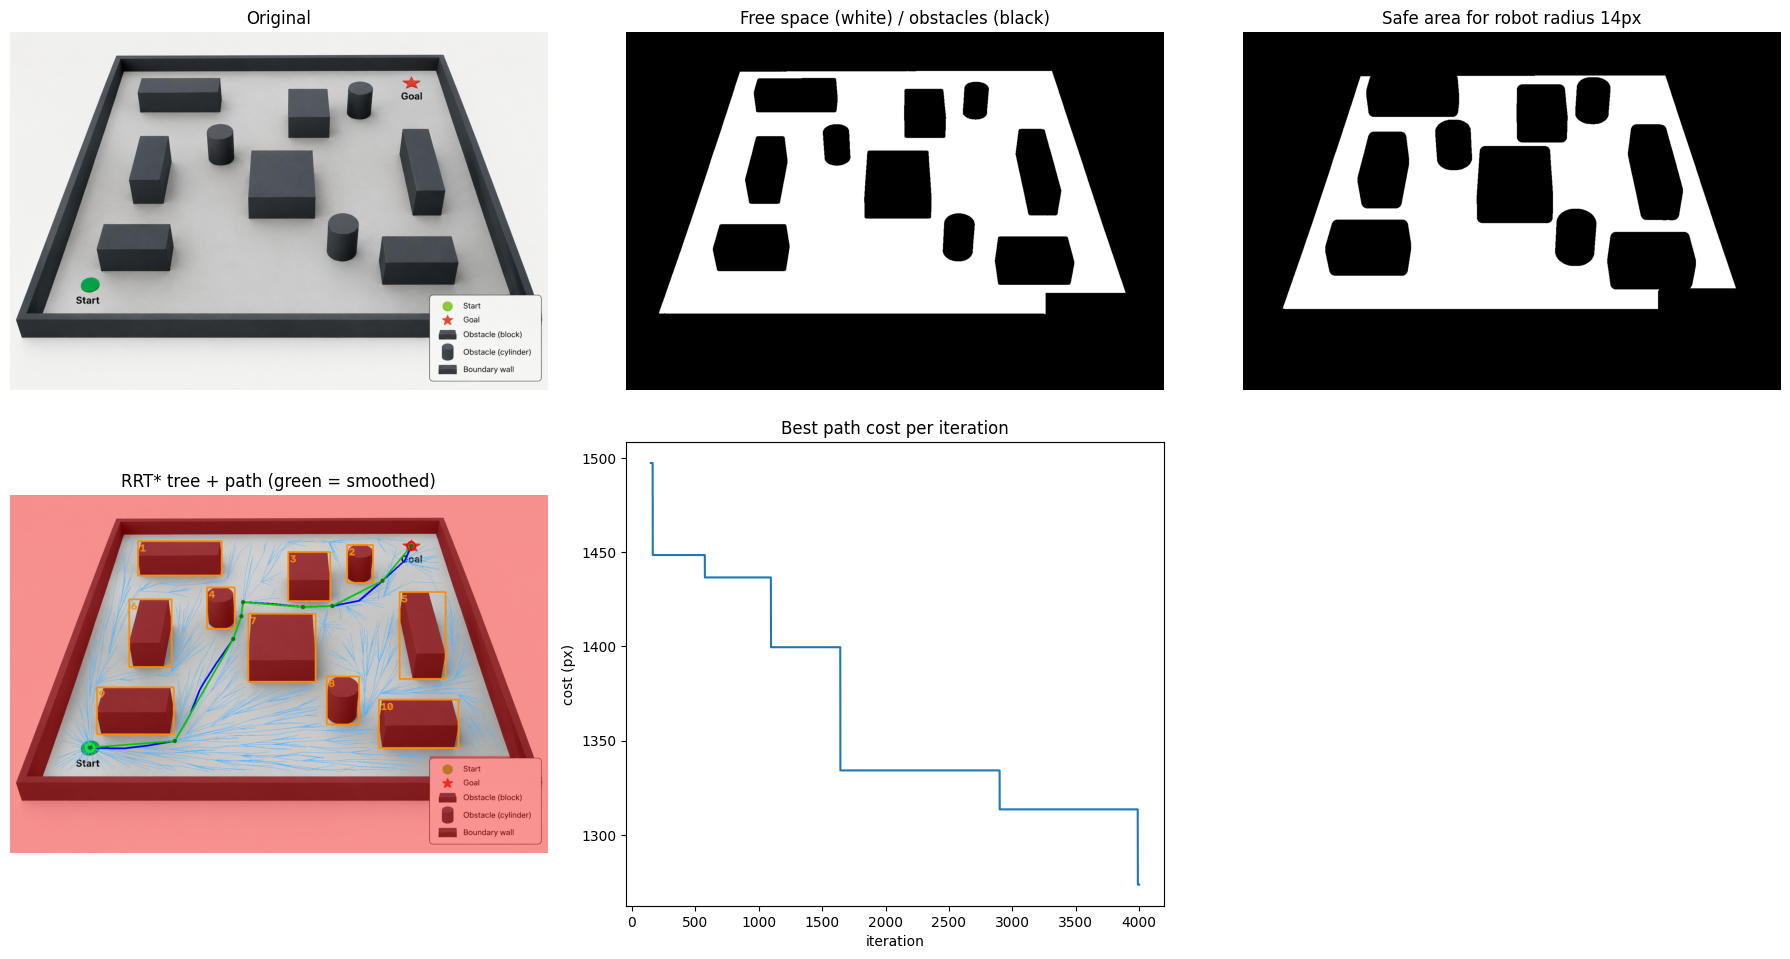

Waypoints (x, y) in pixels:
(228, 723)
(470, 705)
(637, 413)
(661, 348)
(665, 308)
(837, 322)
(920, 320)
(1063, 248)
(1145, 148)


In [14]:
from google.colab import files
uploaded = files.upload()

filename, file_data = list(uploaded.items())[0]
image = cv2.imdecode(np.frombuffer(file_data, dtype=np.uint8), cv2.IMREAD_COLOR)

waypoints, raw_path, result = plan_path(image)

if waypoints is not None:
    print("Waypoints (x, y) in pixels:")
    for p in waypoints:
        print((round(p[0]), round(p[1])))